In [1]:
# All paths in this notebook are relative to the repository root; anchor the working directory there
import os
while not os.path.exists('METHODOLOGY.md') and os.getcwd() != '/': os.chdir('..')
assert os.path.exists('METHODOLOGY.md'), 'run from inside the Nofit_LRT_Extension repository'

# LRT Capture on the 2040 / 2050 Forecast Matrices

Step 31 (`Mode_skims_and_flow_comparison.ipynb`) built the complete mode skims on the 25 V2 areas and ran the pivoted capture on the 2022 flows. This step runs **the same capture on the four forecast matrix sets of step 23** — BU and HS demographic references, 2040 and 2050 — grown at TAZ level from the final 2022 layers (`Output/forecast_taz/{scenario}/`) and aggregated here to the V2 areas.

**What is held fixed.** The skims are those of step 31 (2026 timetable and link speeds, 2017 / 18 car times, the drawn `hf_lrt_3` line with feeder access): no congestion growth in the car times, no change in the bus network, no branch LRT. The no-build mode split of the forecast matrices is the 2022 split by construction (step 23 grows margins, not mode choice), so the capture is again an incremental logit pivoted on each scenario's own transit trips per pair. The three perception assumptions of step 31 carry over: λ = 0.03 per generalized minute (λ_T = 0.06), an LRT premium of 5 generalized minutes, free LRT–Metronit transfers; money out of the comparison.

**What changes with the year** is therefore the market: the trips between the 25 areas, their spatial pattern (where growth falls: Tirat Carmel, the Krayot, Nazareth) and the resulting LRT trips, boardings and trunk-link loads. All flows are 06:00–09:00 trips with both ends in the 25 areas.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA, PURPLE, INK, INK2, MUTED, GRID, AXIS = '#2a78d6', '#eb6834', '#1baf7a', '#7b5bd6', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
OUT = 'Output/skims/forecast'; os.makedirs(OUT, exist_ok=True); os.makedirs('Output/figures', exist_ok=True)
SK_DIR = 'Output/skims'; FC_DIR = 'Output/forecast_taz'
SCEN = ['BU_2040', 'BU_2050', 'HS_2040', 'HS_2050']
LRT_SC = {'lrt_all_underground': 'LRT all underground', 'lrt_all_ground': 'LRT all ground', 'lrt_design_50kmh': 'LRT design 50 km/h'}
# capture parameters (step 31, assumptions of 22 Sep 2026): (λ, λ_T, LRT premium)
CASES = {'central (λ 0.03, λ_T 0.06, premium 5)': (0.03, 0.06, 5.0), 'low λ (0.02 / 0.03, premium 5)': (0.02, 0.03, 5.0), 'high λ (0.05 / 0.10, premium 5)': (0.05, 0.10, 5.0),
         'no premium (λ central, premium 0)': (0.03, 0.06, 0.0), 'premium 10 (λ central)': (0.03, 0.06, 10.0)}
CENTRAL = 'central (λ 0.03, λ_T 0.06, premium 5)'; K_EB = 20.0
xl = pd.ExcelFile('Input/Corridor_TAZ_Agg_V2.xlsx'); areas = xl.parse('AreaCodes').set_index('AggCode'); key = xl.parse('TazAgg')
AREAS = list(areas.index); names = areas['AggAreaName']; A = len(AREAS); OFF = ~np.eye(A, dtype=bool)
def rd(f, obj=False):
    m = pd.read_csv(f'{SK_DIR}/{f}', index_col=0, dtype=object if obj else None); m.columns = m.columns.astype(int); m = m.reindex(index=AREAS, columns=AREAS)
    return m if obj else m.astype(float)
GC = {'bus': rd('skim_bus_gc.csv'), **{sc: rd(f'skim_{sc}_gc.csv') for sc in LRT_SC}}
GW = {sc: (rd(f'skim_{sc}_gateway_o.csv', True).fillna(''), rd(f'skim_{sc}_gateway_d.csv', True).fillna('')) for sc in LRT_SC}
LEGS = {sc: rd(f'skim_{sc}_legs.csv', True).fillna('') for sc in LRT_SC}
ON_LINE = sorted({int(float(v)) for sc in LRT_SC for v in GW[sc][0].values.ravel() if v != ''}); pos = {a: i for i, a in enumerate(ON_LINE)}
missing_scen = [s for s in SCEN if not os.path.exists(f'{FC_DIR}/{s}/transit_{s}_taz.csv')]
assert not missing_scen, f'step 23 scenario outputs missing: {missing_scen} — run Forecast_matrices_TAZ_2040_2050.ipynb after pulling Input/Demographic_Forecast/Zonal_*.csv from LFS'
print(f"{A} areas; LRT station areas {ON_LINE}; skims of step 31 loaded; forecast sets {SCEN}")

25 areas; LRT station areas [201, 202, 203, 204, 205, 206, 207, 208, 209, 210]; skims of step 31 loaded; forecast sets ['BU_2040', 'BU_2050', 'HS_2040', 'HS_2050']


## 1. The forecast matrices on the V2 areas

In [3]:
# TAZ -> V2 area aggregation matrix (174 TAZs of the key; 2022 layers for reference come from step 24's area files)
def to_area(T):
    T = T.copy(); T.index = T.index.astype(int); T.columns = T.columns.astype(int)
    k = key[key['TAZ'].isin(T.index)]; M = np.zeros((len(T.index), A))
    M[[T.index.get_loc(t) for t in k['TAZ']], [AREAS.index(a) for a in k['AggCode']]] = 1.0
    return pd.DataFrame(M.T @ T.reindex(columns=T.index).fillna(0).values @ M, index=AREAS, columns=AREAS)
F = {}
for s in SCEN:
    F[s] = {lay: to_area(pd.read_csv(f'{FC_DIR}/{s}/{lay}_{s}_taz.csv', index_col=0)) for lay in ['car', 'transit', 'taxi']}
    for lay in F[s]: F[s][lay].to_csv(f'{OUT}/{lay}_{s}_area_v2.csv', float_format='%.2f')
F['2022'] = {lay: pd.read_csv(f'Output/corridor_v2/{lay}_2022_area_v2.csv', index_col=0) for lay in ['car', 'transit', 'taxi']}
for lay in F['2022']: F['2022'][lay].columns = F['2022'][lay].columns.astype(int); F['2022'][lay] = F['2022'][lay].reindex(index=AREAS, columns=AREAS).fillna(0.0)
YEARS = ['2022'] + SCEN
trunk_mask = np.zeros((A, A), bool); ix = [AREAS.index(a) for a in ON_LINE]; trunk_mask[np.ix_(ix, ix)] = True; trunk_mask &= OFF
growth = []
for y in YEARS:
    car, tr, tx = (F[y][l].values for l in ['car', 'transit', 'taxi'])
    growth.append({'scenario': y, 'car (off-diagonal)': (car * OFF).sum(), 'transit (off-diagonal)': (tr * OFF).sum(), 'taxi (off-diagonal)': (tx * OFF).sum(), 'transit share of car + transit': (tr * OFF).sum() / ((car + tr) * OFF).sum(),
                   'intra-area (all modes)': np.trace(car + tr + tx), 'transit on trunk pairs': tr[trunk_mask].sum(), 'transit with one end off the line': (tr * OFF).sum() - tr[trunk_mask].sum()})
growth = pd.DataFrame(growth); growth['growth vs 2022, transit'] = growth['transit (off-diagonal)'] / growth['transit (off-diagonal)'].iloc[0]; growth['growth vs 2022, car'] = growth['car (off-diagonal)'] / growth['car (off-diagonal)'].iloc[0]
growth.round(3).to_csv(f'{OUT}/forecast_market_v2_growth.csv', index=False); print(growth.round(3).to_string(index=False))
# where the transit growth falls: origin area totals
og = pd.DataFrame({y: (F[y]['transit'].values * OFF).sum(axis=1) for y in YEARS}, index=AREAS); og.insert(0, 'area', names.values)
for s in SCEN: og[f'{s} / 2022'] = (og[s] / og['2022'].replace(0, np.nan)).round(2)
og[YEARS] = og[YEARS].round(0); og.to_csv(f'{OUT}/forecast_transit_origins_v2.csv'); print(); print(og[['area', '2022'] + SCEN + [f'{s} / 2022' for s in SCEN]].to_string())

scenario  car (off-diagonal)  transit (off-diagonal)  taxi (off-diagonal)  transit share of car + transit  intra-area (all modes)  transit on trunk pairs  transit with one end off the line  growth vs 2022, transit  growth vs 2022, car
    2022           56444.640               11664.271             6981.744                           0.171              109015.016                4174.000                           7490.271                    1.000                1.000
 BU_2040           74606.258               14836.413             9630.207                           0.166              160206.782                5008.149                           9828.264                    1.272                1.322
 BU_2050           86376.513               16368.596            10963.312                           0.159              187404.305                5193.372                          11175.224                    1.403                1.530
 HS_2040           78022.785               16076.037        

## 2. The capture, scenario by scenario

The machinery of step 31 §5, unchanged: `P_LRT|T = 1 / (1 + exp(λ_T · (GC_LRT − premium − GC_bus)))` within the transit nest; the nest's logsum improvement `Δ = −(1/λ_T) · ln(1 + exp(−λ_T · (GC_LRT − premium − GC_bus)))` shifts car to transit by the incremental logit `S' = S·e^{−λΔ} / (S·e^{−λΔ} + 1 − S)` on the pair's transit share `S` (Empirical-Bayes-smoothed towards the scenario's study-area share, k = 20), applied as the growth factor `S'/S` to the pair's no-build transit trips. LRT trips from bus = `P_LRT|T` × the no-build transit trips; from car = `P_LRT|T` × the induced transit trips.

In [4]:
def capture(T_car, T_tr, sc, lam, lt, prem):
    n = T_car + T_tr; p0 = (T_tr * OFF).sum() / (n * OFF).sum()
    S_raw = np.where(n > 0, T_tr / np.where(n > 0, n, 1), np.nan)
    S_piv = np.where(n > 0, (n * np.nan_to_num(S_raw) + K_EB * p0) / (n + K_EB), np.nan)
    dL = (GC[sc] - prem - GC['bus']).values; avail = np.isfinite(dL) & OFF & (n > 0)
    P_L = np.where(avail, 1 / (1 + np.exp(lt * np.nan_to_num(dL))), 0.0)
    delta = np.where(avail, -(1 / lt) * np.log1p(np.exp(-lt * np.nan_to_num(dL))), 0.0)
    S_new = np.where(avail, S_piv * np.exp(-lam * delta) / (S_piv * np.exp(-lam * delta) + 1 - S_piv), S_piv)
    growth_f = np.where(avail, np.nan_to_num(S_new) / np.where(np.nan_to_num(S_piv) > 0, S_piv, 1), 1.0)
    T_tr_new = np.minimum(T_tr * growth_f, n); T_lrt = T_tr_new * P_L
    return {'P': P_L, 'T_lrt': T_lrt, 'from_bus': T_tr * P_L, 'from_car': T_lrt - T_tr * P_L, 'T_bus': T_tr_new - T_lrt, 'T_tr_new': T_tr_new}
RES = {}; rows = []
for y in YEARS:
    T_car, T_tr = F[y]['car'].values * OFF, F[y]['transit'].values * OFF
    for sc, lab in LRT_SC.items():
        for case, (lam, lt, prem) in CASES.items():
            r = capture(T_car, T_tr, sc, lam, lt, prem); RES[(y, sc, case)] = r
            rows.append({'scenario-year': y, 'LRT scenario': lab, 'case': case, 'λ': lam, 'λ_T': lt, 'premium': prem, 'transit trips (no-build)': T_tr.sum(), 'LRT trips 06–09': r['T_lrt'].sum(), 'from bus': r['from_bus'].sum(), 'from car': r['from_car'].sum(),
                         'LRT share of no-build transit': r['T_lrt'].sum() / T_tr.sum(), 'transit share before': T_tr.sum() / (T_car + T_tr).sum(), 'transit share after': r['T_tr_new'].sum() / (T_car + T_tr).sum(),
                         'LRT trips on trunk pairs': r['T_lrt'][trunk_mask].sum(), 'LRT trips with an off-line end': r['T_lrt'].sum() - r['T_lrt'][trunk_mask].sum()})
            if case == CENTRAL:
                pd.DataFrame(r['T_lrt'], index=AREAS, columns=AREAS).to_csv(f'{OUT}/lrt_trips_{y}_{sc}_central.csv', float_format='%.1f')
scen = pd.DataFrame(rows); scen.to_csv(f'{OUT}/lrt_capture_scenarios_forecast.csv', index=False, float_format='%.4f')
cen = scen[scen['case'] == CENTRAL].pivot(index='scenario-year', columns='LRT scenario', values='LRT trips 06–09').reindex(YEARS)
rng = scen[scen['case'].str.contains('λ')].groupby(['scenario-year', 'LRT scenario'])['LRT trips 06–09'].agg(['min', 'max']).unstack('LRT scenario').reindex(YEARS)
print('LRT trips 06:00–09:00, central case (λ range in brackets):')
for y in YEARS:
    print(f"  {y:8s}  underground {cen.loc[y, 'LRT all underground']:7,.0f}  [{rng.loc[y, ('min', 'LRT all underground')]:,.0f}–{rng.loc[y, ('max', 'LRT all underground')]:,.0f}]   ground {cen.loc[y, 'LRT all ground']:7,.0f}  [{rng.loc[y, ('min', 'LRT all ground')]:,.0f}–{rng.loc[y, ('max', 'LRT all ground')]:,.0f}]   design 50 km/h {cen.loc[y, 'LRT design 50 km/h']:7,.0f}  [{rng.loc[y, ('min', 'LRT design 50 km/h')]:,.0f}–{rng.loc[y, ('max', 'LRT design 50 km/h')]:,.0f}]")
print(); print(scen[scen['case'] == CENTRAL][['scenario-year', 'LRT scenario', 'transit trips (no-build)', 'LRT trips 06–09', 'from bus', 'from car', 'LRT share of no-build transit', 'transit share before', 'transit share after', 'LRT trips on trunk pairs', 'LRT trips with an off-line end']].round(3).to_string(index=False))

LRT trips 06:00–09:00, central case (λ range in brackets):
  2022      underground   3,332  [2,357–4,856]   ground   2,544  [1,473–4,277]   design 50 km/h   3,970  [3,210–5,272]
  BU_2040   underground   4,114  [2,889–6,093]   ground   3,105  [1,767–5,338]   design 50 km/h   4,930  [3,981–6,631]
  BU_2050   underground   4,498  [3,143–6,725]   ground   3,386  [1,916–5,881]   design 50 km/h   5,404  [4,354–7,328]
  HS_2040   underground   4,520  [3,199–6,685]   ground   3,430  [1,983–5,867]   design 50 km/h   5,416  [4,367–7,279]
  HS_2050   underground   5,354  [3,828–7,815]   ground   4,047  [2,362–6,840]   design 50 km/h   6,432  [5,187–8,527]

scenario-year        LRT scenario  transit trips (no-build)  LRT trips 06–09  from bus  from car  LRT share of no-build transit  transit share before  transit share after  LRT trips on trunk pairs  LRT trips with an off-line end
         2022 LRT all underground                 11664.271         3332.435  3037.505   294.930                    

## 3. Trunk-link loads and boardings by year

Underground, central case — busiest trunk link per year:
               max_link_3h  max_link_peak                    busiest link
scenario-year                                                            
2022                 995.0          588.0  Namal-Giborim → Hamifrats down
BU_2040             1216.0          718.0  Namal-Giborim → Hamifrats down
BU_2050             1367.0          807.0  Namal-Giborim → Hamifrats down
HS_2040             1426.0          842.0  Namal-Giborim → Hamifrats down
HS_2050             1717.0         1014.0  Namal-Giborim → Hamifrats down

Boardings by station area (central case):
                  area  2022 LRT all underground  2022 LRT all ground  2022 LRT design 50 km/h  BU_2040 LRT all underground  BU_2040 LRT all ground  BU_2040 LRT design 50 km/h  BU_2050 LRT all underground  BU_2050 LRT all ground  BU_2050 LRT design 50 km/h  HS_2040 LRT all underground  HS_2040 LRT all ground  HS_2040 LRT design 50 km/h  HS_2050 LRT all underground  HS_2050 LRT al

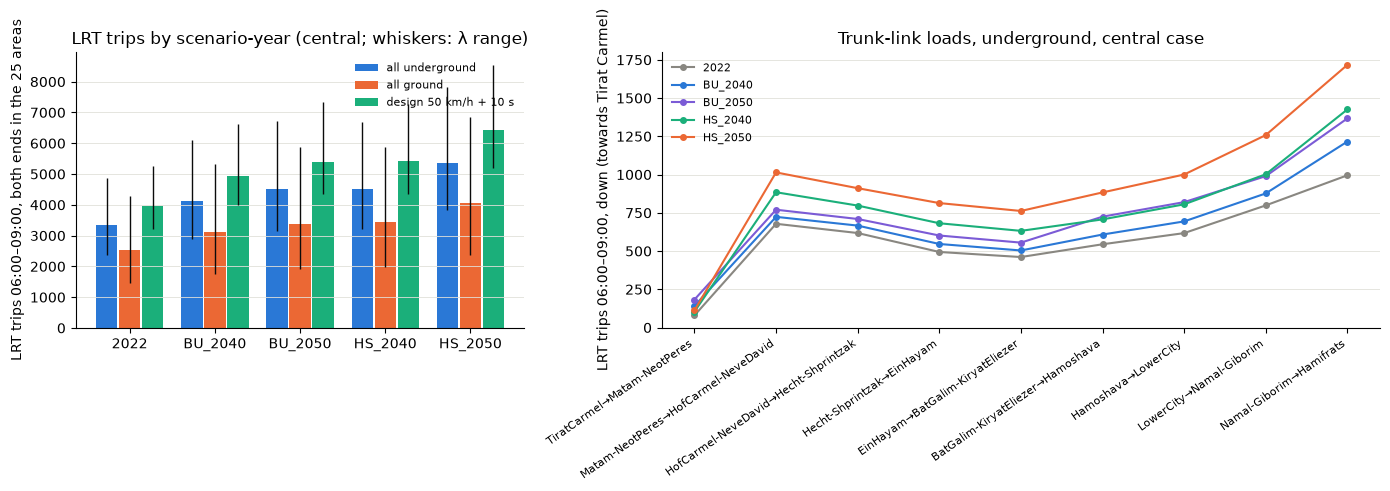

In [5]:
lf = pd.read_csv('Output/corridor_v2/corridor_v2_network_link_flows.csv')
trunk_links = lf[lf['segment'] == 'trunk'][['link', 'from_code', 'to_code', 'from_area', 'to_area']].drop_duplicates().sort_values('link')
trunk_links = trunk_links[trunk_links['to_code'].isin(ON_LINE) & trunk_links['from_code'].isin(ON_LINE)].reset_index(drop=True)
phf = pd.read_csv('Output/corridor_v2/peak_hour_factors_v2_applied.csv'); phf_net = phf[(phf['scope'] == 'network') & (phf['layer'] == 'bus')].drop_duplicates('direction').set_index('direction')['PHF3h applied']
PHF_T = {d: float(phf_net[d]) for d in ('up', 'down')}
def load_links(T, g_o, g_d):
    L = {(l, d): 0.0 for l in trunk_links['link'] for d in ('up', 'down')}
    for i, o in enumerate(AREAS):
        for j, d in enumerate(AREAS):
            t = T[i, j]
            if t <= 0 or g_o.loc[o, d] == '': continue
            a, b = pos[int(float(g_o.loc[o, d]))], pos[int(float(g_d.loc[o, d]))]
            if a == b: continue
            dirn = 'up' if b > a else 'down'
            for k in range(min(a, b), max(a, b)): L[(trunk_links.loc[k, 'link'], dirn)] += t
    return L
def boardings(T, g_o):
    s = pd.Series(0.0, index=ON_LINE)
    for i, o in enumerate(AREAS):
        for j, d in enumerate(AREAS):
            if T[i, j] > 0 and g_o.loc[o, d] != '': s[int(float(g_o.loc[o, d]))] += T[i, j]
    return s
prof_rows, board = [], {}
for y in YEARS:
    T_tr = F[y]['transit'].values * OFF; T_car = F[y]['car'].values * OFF
    bus_links = {}; car_links = {}
    # no-build bus / transit potential movements on the trunk links from the scenario's own matrices (same tree loading as step 24 on the trunk: every pair of the 25 areas on its unique path)
    # the trunk links carry all trips whose unique tree path crosses them; for the trunk this is every pair whose gateways differ — computed with the LRT gateway map as the trunk projection
    for lay, T in (('transit', T_tr), ('car', T_car)):
        L = load_links(T, GW['lrt_all_underground'][0], GW['lrt_all_underground'][1]); (bus_links if lay == 'transit' else car_links).update(L)
    for sc, tag in (('lrt_all_underground', 'lrt_ug'), ('lrt_all_ground', 'lrt_ground'), ('lrt_design_50kmh', 'lrt_d50')):
        L = load_links(RES[(y, sc, CENTRAL)]['T_lrt'], *GW[sc]); Llo = load_links(RES[(y, sc, 'low λ (0.02 / 0.03, premium 5)')]['T_lrt'], *GW[sc]); Lhi = load_links(RES[(y, sc, 'high λ (0.05 / 0.10, premium 5)')]['T_lrt'], *GW[sc])
        for _, r in trunk_links.iterrows():
            for d in ('up', 'down'):
                prof_rows.append({'scenario-year': y, 'LRT scenario': LRT_SC[sc], 'link': r['link'], 'from_area': r['from_area'], 'to_area': r['to_area'], 'direction': d,
                                  'transit_nobuild_3h_trunk_projection': bus_links[(r['link'], d)], 'car_nobuild_3h_trunk_projection': car_links[(r['link'], d)],
                                  'lrt_3h': L[(r['link'], d)], 'lrt_3h_low': Llo[(r['link'], d)], 'lrt_3h_high': Lhi[(r['link'], d)], 'lrt_peak_hour': L[(r['link'], d)] * PHF_T[d]})
        board[(y, sc)] = boardings(RES[(y, sc, CENTRAL)]['T_lrt'], GW[sc][0])
prof = pd.DataFrame(prof_rows).round(1); prof.to_csv(f'{OUT}/trunk_link_flows_forecast.csv', index=False)
bd = pd.DataFrame({f'{y} {LRT_SC[sc]}': board[(y, sc)] for y in YEARS for sc in LRT_SC}); bd.insert(0, 'area', names.reindex(ON_LINE).values); bd.round(0).to_csv(f'{OUT}/lrt_boardings_forecast.csv')
mx = prof[prof['LRT scenario'] == 'LRT all underground'].groupby('scenario-year').agg(max_link_3h=('lrt_3h', 'max'), max_link_peak=('lrt_peak_hour', 'max')).reindex(YEARS)
mxl = prof[prof['LRT scenario'] == 'LRT all underground'].sort_values('lrt_3h', ascending=False).groupby('scenario-year').head(1).set_index('scenario-year').reindex(YEARS)
mx['busiest link'] = mxl['from_area'] + ' → ' + mxl['to_area'] + ' ' + mxl['direction']
print('Underground, central case — busiest trunk link per year:'); print(mx.round(0).to_string()); print()
print('Boardings by station area (central case):'); print(bd.round(0).to_string(index=False))
# figure: LRT trips by year and the trunk profile (down direction, underground)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={'width_ratios': [1, 1.6]})
ax = axes[0]; xs = np.arange(len(YEARS))
ax.bar(xs - 0.27, cen['LRT all underground'], 0.25, color=BLUE, label='all underground'); ax.bar(xs, cen['LRT all ground'], 0.25, color=ORANGE, label='all ground'); ax.bar(xs + 0.27, cen['LRT design 50 km/h'], 0.25, color=AQUA, label='design 50 km/h + 10 s')
ax.vlines(xs - 0.27, rng[('min', 'LRT all underground')], rng[('max', 'LRT all underground')], color=INK, lw=1); ax.vlines(xs, rng[('min', 'LRT all ground')], rng[('max', 'LRT all ground')], color=INK, lw=1); ax.vlines(xs + 0.27, rng[('min', 'LRT design 50 km/h')], rng[('max', 'LRT design 50 km/h')], color=INK, lw=1)
ax.set_xticks(xs); ax.set_xticklabels(YEARS); ax.set_ylabel('LRT trips 06:00–09:00, both ends in the 25 areas'); ax.set_title('LRT trips by scenario-year (central; whiskers: λ range)'); ax.legend(frameon=False, fontsize=8)
ax = axes[1]
for y, c in zip(YEARS, [MUTED, BLUE, PURPLE, AQUA, ORANGE]):
    p = prof[(prof['scenario-year'] == y) & (prof['LRT scenario'] == 'LRT all underground') & (prof['direction'] == 'down')]
    ax.plot(np.arange(len(p)), p['lrt_3h'], 'o-', color=c, label=y, lw=1.5, ms=4)
p = prof[(prof['scenario-year'] == '2022') & (prof['LRT scenario'] == 'LRT all underground') & (prof['direction'] == 'down')]
ax.set_xticks(np.arange(len(p))); ax.set_xticklabels([f"{a}→{b}" for a, b in zip(p['from_area'], p['to_area'])], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('LRT trips 06:00–09:00, down (towards Tirat Carmel)'); ax.set_title('Trunk-link loads, underground, central case'); ax.legend(frameon=False, fontsize=8)
for ax in axes:
    ax.grid(axis='y', color=GRID, lw=0.6)
    for s_ in ('top', 'right'): ax.spines[s_].set_visible(False)
plt.tight_layout(); plt.savefig('Output/figures/lrt_capture_forecast_2040_2050.png', dpi=150); plt.show()

## 4. Where the growth in LRT trips comes from

In [6]:
# LRT trips by path type and by origin area, 2022 vs the scenarios (central, underground)
pt = []
for y in YEARS:
    T = RES[(y, 'lrt_all_underground', CENTRAL)]['T_lrt']; lg = LEGS['lrt_all_underground'].values
    d = pd.DataFrame({'legs': lg.ravel(), 'lrt': T.ravel(), 'transit': (F[y]['transit'].values * OFF).ravel()})
    d = d[d['legs'] != ''].groupby('legs').agg(lrt=('lrt', 'sum'), transit=('transit', 'sum')); d.columns = pd.MultiIndex.from_product([[y], d.columns]); pt.append(d)
pt = pd.concat(pt, axis=1).round(0); pt.to_csv(f'{OUT}/lrt_trips_by_path_type_forecast.csv'); print(pt.to_string())
oa = pd.DataFrame({y: RES[(y, 'lrt_all_underground', CENTRAL)]['T_lrt'].sum(axis=1) for y in YEARS}, index=AREAS); oa.insert(0, 'area', names.values)
for s in SCEN: oa[f'{s} / 2022'] = (oa[s] / oa['2022'].replace(0, np.nan)).round(2)
oa[YEARS] = oa[YEARS].round(0); oa.to_csv(f'{OUT}/lrt_trips_by_origin_area_forecast.csv'); print(); print(oa.sort_values('HS_2050', ascending=False).head(12).to_string())

                 2022         BU_2040         BU_2050         HS_2040         HS_2050        
                  lrt transit     lrt transit     lrt transit     lrt transit     lrt transit
legs                                                                                         
brt→LRT         570.0  1611.0   698.0  1989.0   813.0  2295.0   843.0  2178.0  1094.0  2720.0
brt→LRT→brt     425.0  3386.0   602.0  4921.0   711.0  5745.0   641.0  5218.0   708.0  5446.0
brt→LRT→bus      17.0   117.0    21.0   142.0    20.0   140.0    40.0   269.0    47.0   324.0
bus→LRT         283.0   815.0   281.0   829.0   319.0   937.0   276.0   819.0   334.0   991.0
bus→LRT→brt     184.0   957.0   221.0  1193.0   254.0  1325.0   219.0  1243.0   235.0  1351.0
bus→LRT→bus       1.0    13.0     1.0    16.0     1.0    16.0     1.0    24.0     2.0    32.0
directLRT      1580.0  4174.0  1952.0  5008.0  2040.0  5193.0  2053.0  5339.0  2437.0  6334.0
directLRT→brt   213.0   427.0   250.0   495.0   262.0   506.

## Findings

- **The market grows by a quarter to a half; its mode split does not.** Transit trips between the 25 areas rise from 11,664 in 2022 to 14,836 (BU 2040, × 1.27), 16,369 (BU 2050, × 1.40), 16,076 (HS 2040, × 1.38) and 18,291 (HS 2050, × 1.57); car trips rise a little faster (× 1.32 / 1.53 / 1.38 / 1.59), so the no-build transit share of car + transit stays at 0.16–0.17 — by construction of step 23, which grows margins and keeps the 2022 mode choice. Where the growth falls differs by reference: BU puts it in Tirat Carmel (transit origins 553 → 1,299), the T2 Krayot branch (Kiryat Bialik Center 902 → 1,690 by 2050, Tsur Shalom and Kiryon nearly doubling) and Kiryat Haim West (750 → 1,370); HS puts it on the Carmel coast and in the Krayot's western TAZs — Matam 229 → 869, Hof Carmel 276 → 685, Bat Galim 811 → 1,410, Kiryat Haim West 750 → 2,317, Kiryat Ata North 256 → 662 — with Nazareth growing modestly in both (1,070 → 1,257–1,445).
- **LRT trips grow with the market, at the same capture rate.** Central case, all underground: **3,332 (2022) → 4,114 (BU 2040) → 4,498 (BU 2050)**, and **4,520 (HS 2040) → 5,354 (HS 2050)** trips in 06:00–09:00; all at ground level 2,544 → 3,105 / 3,386 and 3,430 / 4,047. The LRT's share of the no-build transit trips stays at 0.28–0.29 underground and 0.21–0.22 at ground level in every year, because the skims — and with them the pair-level capture — are held at today's conditions; the year changes only the trips they are applied to. The λ range spans 2,889–6,093 underground in BU 2040 and 3,828–7,815 in HS 2050; the premium and the free Metronit transfer keep their step 31 weight.
- **Where the extra trips board.** Hamifrats stays the largest station area in every scenario — 995 boardings underground in 2022, 1,216 / 1,367 under BU and 1,426 / 1,717 under HS — followed by Namal-Giborim (748 → 890–1,031); both are the gateways of the Metronit-fed Krayot pairs, which grow fastest (Metronit → LRT trips 570 → 1,094 by HS 2050). The two references then diverge: BU more than doubles Tirat Carmel's boardings (251 → 591 / 623) while the Carmel-coast stations stand still; HS lifts Bat Galim (353 → 468 / 617), Matam (118 → 271 / 366) and Hof Carmel (147 → 270 / 339) and leaves Tirat Carmel at 334–368.
- **The specified design regime (50 km/h + 10 s per stop) scales the same way.** Central case 3,970 (2022) → 4,930 / 5,404 (BU 2040 / 2050) → 5,416 / 6,432 (HS 2040 / 2050) LRT trips, a share of the no-build transit trips of 0.33–0.35 in every year; the busiest link, Namal-Giborim → Hamifrats down, reaches 1,503 / 1,693 (BU) and 1,749 / 2,104 (HS) trips in the three hours — 1,242 in the HS 2050 peak hour; Hamifrats boards 2,104 by HS 2050. The ceiling regime adds about a fifth to the underground case in every scenario-year, the same proportion as in 2022.
- **On the trunk links** the busiest link is Namal-Giborim → Hamifrats towards the Krayot in every year: 995 trips in the three hours in 2022, 1,216 / 1,367 under BU and 1,426 / 1,717 under HS, that is 588 → 718 / 807 / 842 / 1,014 in the peak hour with step 27's factor. The whole trunk profile scales with the market and tilts towards whichever end the reference grows; the Krayot end dominates throughout.
- **How to read the numbers.** Corridor-internal trips only (both ends in the 25 areas); the 2026 skims applied unchanged to 2040 and 2050 — no congestion growth in the car times, no change in the bus network or the feeders, no branch LRT (which would replace the feeder composite for 15 areas and change the picture on the T1 / T2 / T3 branches most); the 2022 mode split carried into the no-build by construction; no capacity; the three perception assumptions of step 31 (λ, the 5-minute premium, the free LRT–Metronit transfer). The forecast sets themselves are step 23's demographic reference — margins grown from the zonal forecasts with composite land-use indices, destination choice and trip rates at 2022 — and inherit its status. Taxi trips are carried unchanged (their Furness in step 23 stops at 10–15 % on the row margins, which does not touch this step).
- **Outputs** (`Output/skims/forecast/`): `{car,transit,taxi}_{scenario}_area_v2.csv` (the forecast sets on the 25 areas), `forecast_market_v2_growth.csv`, `forecast_transit_origins_v2.csv`, `lrt_capture_scenarios_forecast.csv` (every scenario-year × LRT scenario × case), `lrt_trips_{year}_{scenario}_central.csv`, `trunk_link_flows_forecast.csv`, `lrt_boardings_forecast.csv`, `lrt_trips_by_path_type_forecast.csv`, `lrt_trips_by_origin_area_forecast.csv`; figure `lrt_capture_forecast_2040_2050.png`.